# Do the movement scores agree with each other?

**The question:** the app has eleven movement metrics, and the leg tracker is a twelfth score. Changing the metric seems to change which mites are called moving. Do the scores call the same mites moving in the same recordings? And do they put the mites in the same order, from the one that moves most to the one that moves least?

**The approach:** every score is made for every mite in every recording of the long run (`test_run_2026-09-08_Mathis_last_dsRNA`), from the same patches and with the parameters in `config.yaml` (`scripts/metric_agreement.py`). Two scores are compared by the calls they make (Cohen's kappa) and by the order they put the mites in (rank correlation). The labels made by eye are the reference where one is needed.

The first run scores every mite in every recording and keeps the scores (under a minute once the patches are cut, which `scripts/optuna_death_time.py` and the other notebooks of this run do as well); later runs start at once.

## Findings (run of 9 October 2026)

One run, one plate, 59 mites, 295 recordings of 10 frames, 10 minutes apart. 651 of the 17 318 labelled mite-recordings are moving.

- **Two of the eleven metrics are one.** `topN_variability` with n = 759 takes the mean of more values than a mite's box holds (396 to 588), which makes it `variability`. That leaves ten scores of the app and the leg tracker.
- **At the saved thresholds the feeling is right: on this run the calls depend on the metric.** At least one of the ten scores calls 7121 mite-recordings moving, all ten call 208, and the labels have 651. Two scores have a kappa of 0.55 in the mean and of 0.06 at the lowest.
- **That is the thresholds on this run, not the scores.** On the short recordings (30 frames) the same thresholds give a kappa of 0.92, 0.82 at the lowest. On this run (10 frames) `optical_flow` calls 10% of the still recordings moving and `topN_binary_flux` 31%, against 1.3% and 5.3% on the short ones. `topN_temporal_range` and `topN_vector_temporal_range` go the other way and find 65% and 41% of the labelled movements, against 96% on the short ones.
- **With the threshold taken out, seven scores make nearly the same calls.** When each calls 651 mite-recordings moving, any two of `topN_temporal_range`, `topN_variability`, `vector_variance`, `outline_movement`, `topN_vector_temporal_range`, `max_diff` and `vector_diff` have a kappa of 0.88 to 0.96. The four others are apart from the seven and from each other: `optical_flow` 0.70, `leg_tracker` 0.70, `mean_diff` 0.66 and `topN_binary_flux` 0.48 with the seven.
- **What the scores do not share is stray calls, each score its own.** Of the 1575 mite-recordings at least one score calls moving, 833 are called by one score alone, and 13 of those are labelled moving. 790 of the 833 come from the four apart. Where one of the four calls a recording moving and none of the seven does, it is labelled moving 11 times in 803.
- **The misses are shared.** Of the 651 labelled movements, 466 are called by nine or more of the eleven, 70 by fewer than half and 12 by none.
- **For the deaths the seven agree once each has a threshold that fits.** At each one's best threshold a mite's death differs between the seven by 1 recording in the median, by 3 or fewer for 37 of the 59 mites and by more than 30 for 2. At the saved thresholds it is 7 recordings in the median and more than 30 for 9 mites, and `optical_flow` and `topN_binary_flux` keep half the mites alive for 47.5 and 49 of the run's 49 hours, where the labels have 8.
- **Where the seven get a death wrong, they get it wrong together, and early.** At their best thresholds all seven put the same 7 mites more than 3 recordings early, and no mite late. A death hangs on the mite's last labelled movement, and those are the weak ones: no score calls 10 of the 54 last movements, against 40 of all 651.
- **The scores can rank the mites over the run, but not by their mean score.** By the mean score the eleven orders have little in common (Kendall's W 0.47), and the order by `mean_diff` has nothing to do with the labels' (-0.07). A mite is still in most recordings, so its mean is mostly its noise floor, and the floors differ from mite to mite (`death_time_calibration.ipynb`) and from score to score. By the mean above each mite's own floor W is 0.84 for all and 0.97 for the seven, and each of the seven puts the mites in the labels' order at 0.93 to 0.98. Counting the recordings called moving does as well (0.96 to 0.99).
- **Within a recording they agree on who moves, and less on who moves most.** The mite a score ranks highest is labelled moving in 92 to 100% of the 144 recordings that have one. But it is the same mite for all eleven scores in 19% of them, and for the seven in 49%. Among the mites labelled moving in one recording two scores have a rank correlation of 0.59 in the mean (0.76 among the seven); among the still ones 0.20, and what order there is belongs to scores made alike (`mean_diff` and `topN_variability` 0.93, `vector_diff` and `vector_variance` 0.89).
- **A vote of the scores is no better than the best of them.** With each at its best threshold, calling a mite moving when at least 4 of the 11 do puts the deaths 3.6 recordings off, and `topN_variability` alone 3.5. A vote takes out the stray calls, which a higher threshold does too.
- **33 labels are worth a second look.** 21 recordings are labelled still and called moving by eight or more of the eleven scores; in the pictures something at the mite's edge changes over the frames. 12 are labelled moving and called so by none. The notebook lists them.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.stats import rankdata

import alive_dead_features as adf
import leg_tracks
import metric_agreement as ma
from classes.app_config import get_default_config
from classes.death_calibration import LabelledRun

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3dc", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
# How much: one hue, light to dark. Which side: blue to red through grey.
AMOUNT = LinearSegmentedColormap.from_list("amount", [SURFACE, "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
SIDES = LinearSegmentedColormap.from_list("sides", ["#184f95", "#6da7ec", "#f0efec", "#ec8a89", "#a52a2a"])
AMOUNT.set_bad(SURFACE)
SIDES.set_bad(SURFACE)
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 40)
np.seterr(invalid="ignore")

run = adf.load_run()
table = ma.scores(run)                   # {score: (mites, recordings)}
n_mites, n_recordings = run.moving.shape
labelled, moving = run.labelled, run.moving
is_still = labelled & ~moving
hours = run.times / 60
step = float(np.median(np.diff(run.times)))  # minutes from one recording to the next
truth = LabelledRun(np.zeros(moving.shape), moving, labelled)  # the labels, to count the deaths against
IN_USE = get_default_config().mite.metric

def death_error(called):
    """Per mite, its death by `called` minus its death by the labels, in recordings."""
    return truth.death_errors(called)

def off_diagonal(matrix):
    return matrix[~np.eye(len(matrix), dtype=bool)]

def number_grid(ax, values, rows, columns=None, cmap=AMOUNT, low=0.0, high=1.0, digits=2, size=7, split=()):
    """A table of numbers as coloured cells, the number written in each; a wider gap before the rows and columns of `split`."""
    columns = rows if columns is None else columns
    shown = ax.imshow(values, cmap=cmap, vmin=low, vmax=high, aspect="auto")
    ax.set_xticks(range(len(columns)), columns, rotation=40, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(rows)), rows)
    ax.grid(False); ax.tick_params(length=0)
    for edge in np.arange(0.5, max(values.shape)):
        if edge < values.shape[0]: ax.axhline(edge, color=SURFACE, linewidth=5 if edge + 0.5 in split else 1.5)
        if edge < values.shape[1]: ax.axvline(edge, color=SURFACE, linewidth=5 if edge + 0.5 in split and len(columns) == len(rows) else 1.5)
    for (row, column), value in np.ndenumerate(values):
        if np.isfinite(value):
            dark = abs(value - (low + high) / 2) / (high - low) > 0.22 if cmap is SIDES else (value - low) / (high - low) > 0.55
            ax.text(column, row, f"{value:.{digits}f}", ha="center", va="center", fontsize=size, color="white" if dark else INK)
    for spine in ax.spines.values(): spine.set_visible(False)
    return shown

print(f"{run.name}: {n_mites} mites, {n_recordings} recordings {step:g} minutes apart ({hours[-1]:.0f} hours)")
print(f"labelled by eye: {labelled.sum()} mite-recordings, {moving.sum()} of them moving ({moving.sum() / labelled.sum():.1%}); "
      f"{run.moved.sum()} mites moved at least once, {(~run.moved).sum()} never")
print(f"scores: {len(table)}: " + ", ".join(table))

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings


test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings 10 minutes apart (49 hours)
labelled by eye: 17318 mite-recordings, 651 of them moving (3.8%); 54 mites moved at least once, 5 never
scores: 12: max_diff, mean_diff, vector_diff, vector_variance, variability, topN_variability, optical_flow, topN_temporal_range, topN_vector_temporal_range, topN_binary_flux, outline_movement, leg_tracker


## The scores and their thresholds

Each score is one number per mite and recording, made from the 10 frames of the recording. The 11 metrics of the app are scored with the parameters in `config.yaml`, on the same patches, with the plate stabilised; `leg_tracker` is the largest swing of a followed leg (`leg_tracking.ipynb`), which the app does not have.

A score only calls a mite moving once it has a threshold, and how far two scores agree depends on both thresholds. So three sets are used:

- **saved**: the thresholds in `config.yaml`. This is what the app does today when the metric is changed there. The leg tracker has none.
- **same count**: each score's threshold is set so that it calls as many mite-recordings moving as the labels do. Every score then makes the same number of calls, and two scores can differ only in *which* recordings they pick. This set takes the threshold out of the comparison.
- **best for deaths**: the threshold that puts this run's deaths closest to where the labels put them, as the calibration report suggests it (`classes/death_calibration.py`). This is each score doing as well as it can on this run.

**AUC**: the chance that a recording labelled moving scores higher than one labelled still. **of them still**: the calls that the labels say are still. **death error**: the mean distance, in recordings, between a mite's death by the score and by the labels (a mite dies at the recording after its last movement).

In [2]:
for pair in ma.same(table):
    dropped = pair[0] if pair[1] == IN_USE else pair[1]
    print(f"{pair[0]} and {pair[1]} give the same numbers here (largest difference {np.abs(table[pair[0]] - table[pair[1]]).max():.0e}): "
          f"{dropped} is left out below")
    table.pop(dropped)
values_in_box = 3 * run.sizes.prod(axis=1)
print(f"a mite's box holds {values_in_box.min()} to {values_in_box.max()} values (pixels x 3 channels)")
names = list(table)

params = ma.metric_params()
saved = ma.config_thresholds()
best = ma.best_thresholds(table, run)    # {score: (threshold, death error)}
THRESHOLDS = {"saved": {name: saved[name] for name in names if name in saved},
              "same count": ma.matched_thresholds(table, run),
              "best for deaths": {name: threshold for name, (threshold, _error) in best.items()}}
CALLS = {key: ma.calls(table, thresholds) for key, thresholds in THRESHOLDS.items()}

rows = {}
for name in names:
    row = {("", "parameters"): ", ".join(f"{key} {value:g}" for key, value in params.get(name, {}).items()) or "-",
           ("", "AUC"): adf.auc(table[name][moving], table[name][is_still])}
    for key, called in CALLS.items():
        if name in called:
            row[(key, "threshold")] = THRESHOLDS[key][name]
            row[(key, "called moving")] = int((called[name] & labelled).sum())
            row[(key, "of them still")] = int((called[name] & is_still).sum())
            row[(key, "death error")] = float(np.abs(death_error(called[name])).mean())
    rows[name] = row
overview = pd.DataFrame.from_dict(rows, orient="index")
overview.columns = pd.MultiIndex.from_tuples(overview.columns)
counts = [column for column in overview.columns if column[1] in ("called moving", "of them still")]
overview[counts] = overview[counts].astype("Int64")
with pd.option_context("display.max_colwidth", 30):
    display(overview)

variability and topN_variability give the same numbers here (largest difference 6e-06): variability is left out below
a mite's box holds 396 to 588 values (pixels x 3 channels)


saved  \
                                               parameters    AUC threshold   
max_diff                                                -  0.994    14.000   
mean_diff                                               -  0.935     1.727   
vector_diff                                             -  0.971   117.700   
vector_variance                                         -  0.992   229.900   
topN_variability                                    n 759  0.997     3.476   
optical_flow                window 5, n 50, step 13, w...  0.954     0.100   
topN_temporal_range                                  n 10  0.998    28.400   
topN_vector_temporal_range                            n 1  0.998    38.500   
topN_binary_flux                      threshold 98, n 260  0.899     0.023   
outline_movement                              n 4, pad 16  0.997     0.266   
leg_tracker                                             -  0.967       NaN   

                                                                   same count  \
                           called moving of them still death error  threshold   
max_diff                             733           117      10.119     18.229   
mean_diff                            641           198      44.271      1.725   
vector_diff                          521            15       4.881     87.539   
vector_variance                      628            51       7.390    211.829   
topN_variability                     606            35       5.576      3.085   
optical_flow                        2239          1668     221.661      0.142   
topN_temporal_range                  431             5       7.831     20.405   
topN_vector_temporal_range           270             3      15.559     25.000   
topN_binary_flux                    5725          5147     195.373      0.043   
outline_movement                     545            21       4.729      0.222   
leg_tracker                         <NA>          <NA>         NaN      0.524   

                                                                    \
                           called moving of them still death error   
max_diff                             651            70       8.441   
mean_diff                            651           207      44.271   
vector_diff                          651            85      19.492   
vector_variance                      651            64       7.627   
topN_variability                     651            55       7.458   
optical_flow                         651           184      72.695   
topN_temporal_range                  651            65       8.424   
topN_vector_temporal_range           654            73       7.559   
topN_binary_flux                     651           325      66.356   
outline_movement                     651            56       7.271   
leg_tracker                          651           189      47.831   

                           best for deaths                              \
                                 threshold called moving of them still   
max_diff                            22.499           544            23   
mean_diff                            1.835           363            11   
vector_diff                        102.430           566            31   
vector_variance                    375.310           490             8   
topN_variability                     4.175           511             2   
optical_flow                         0.200           319            12   
topN_temporal_range                 23.326           580            28   
topN_vector_temporal_range          31.164           502            18   
topN_binary_flux                     0.072           132            15   
outline_movement                     0.266           542            20   
leg_tracker                          0.739           378            41   

                                        
                           death error  
max_diff                         6.508  
mea

## Still or moving: do they make the same calls?

Only 4 mite-recordings in 100 are moving, so two scores that call everything still already agree 96 times in 100. The agreement is therefore given as **Cohen's kappa**: how much more often two scores agree than two that call as many moving, each at random, would. 1 is always, 0 is no more than by chance. When few are moving, kappa is about the share of their moving calls the two have in common.

The table gives, for each set of thresholds, how many mite-recordings at least one score calls moving and how many all of them do. The scores are then put in groups that make about the same calls at the same count (a mean kappa of 0.85 or more between two groups joins them). The largest group is called **the ones that agree** below, the rest **the ones apart**.

In [3]:
AGREEMENT = ma.pairwise(CALLS["same count"], ma.kappa, labelled)
groups = ma.agreeing(AGREEMENT, names)
CLOSE = groups[0]
within = {name: np.mean([AGREEMENT[names.index(name), names.index(other)] for other in CLOSE if other != name]) for name in names}
CLOSE = sorted(CLOSE, key=lambda name: -within[name])
APART = sorted((name for name in names if name not in CLOSE), key=lambda name: -within[name])
ORDER = CLOSE + APART
THE_CLOSE = f"the {len(CLOSE)} that agree"
APART_COLORS = dict(zip(APART, (ORANGE, AQUA, YELLOW, MAGENTA)))

def among(key, group):
    called = {name: CALLS[key][name] for name in group if name in CALLS[key]}
    n_votes = ma.votes(called)[labelled]
    kappas = off_diagonal(ma.pairwise(called, ma.kappa, labelled))
    return {"scores": len(called), "called moving by at least one": int((n_votes > 0).sum()), "by all of them": int((n_votes == len(called)).sum()),
            "kappa of two scores: mean": kappas.mean(), "lowest": kappas.min(), "highest": kappas.max()}

summary = pd.DataFrame({(key, who): among(key, group) for key in CALLS for who, group in (("all", names), (THE_CLOSE, CLOSE))}).T
summary[["scores", "called moving by at least one", "by all of them"]] = summary[["scores", "called moving by at least one", "by all of them"]].astype(int)
display(summary)
print(f"labelled moving: {moving.sum()}")
print(f"{THE_CLOSE}: {', '.join(CLOSE)}")
print("apart, with their mean kappa with those: " + ", ".join(f"{name} {within[name]:.2f}" for name in APART))

scores  called moving by at least one  \
saved           all                   10                           7121   
                the 7 that agree       7                            750   
same count      all                   11                           1575   
                the 7 that agree       7                            772   
best for deaths all                   11                            725   
                the 7 that agree       7                            652   

                                  by all of them  kappa of two scores: mean  \
saved           all                          208                      0.546   
                the 7 that agree             257                      0.797   
same count      all                          207                      0.728   
                the 7 that agree             536                      0.923   
best for deaths all                           73                      0.702   
                the 7 that agree             403                      0.898   

                                  lowest  highest  
saved           all                0.057    0.956  
                the 7 that agree   0.528    0.956  
same count      all                0.408    0.963  
                the 7 that agree   0.878    0.963  
best for deaths all                0.320    0.941  
                the 7 that agree   0.867    0.941

labelled moving: 651
the 7 that agree: topN_temporal_range, topN_variability, vector_variance, outline_movement, topN_vector_temporal_range, max_diff, vector_diff
apart, with their mean kappa with those: optical_flow 0.70, leg_tracker 0.70, mean_diff 0.66, topN_binary_flux 0.48


Every pair of scores, at the saved thresholds and at the same count. The scores that agree come first, then the ones apart. The diagonal is left empty, and so is the leg tracker at the saved thresholds, as it has none.

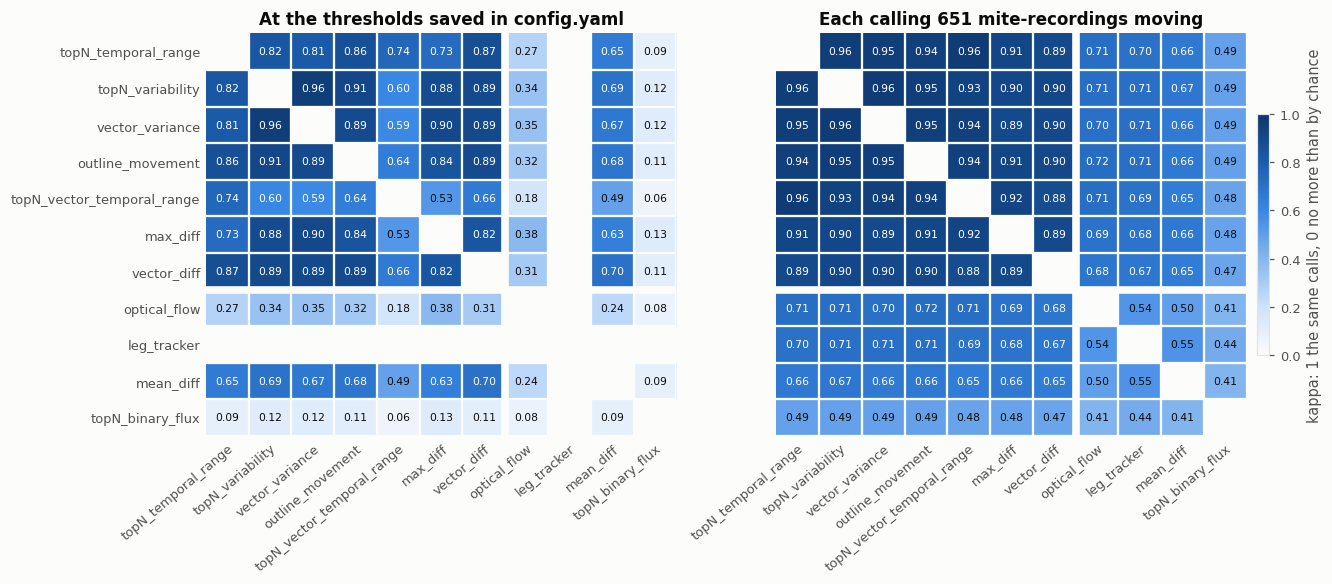

In [4]:
def in_order(called, measure=ma.kappa, where=labelled):
    """pairwise() of the scores in ORDER, empty for those `called` does not have and on the diagonal."""
    out = np.full((len(ORDER), len(ORDER)), np.nan)
    have = [name for name in ORDER if name in called]
    index = [ORDER.index(name) for name in have]
    out[np.ix_(index, index)] = ma.pairwise({name: called[name] for name in have}, measure, where)
    out[np.eye(len(ORDER), dtype=bool)] = np.nan
    return out

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, constrained_layout=True)
for ax, key, title in zip(axes, ("saved", "same count"),
                          ("At the thresholds saved in config.yaml", f"Each calling {moving.sum()} mite-recordings moving")):
    shown = number_grid(ax, in_order(CALLS[key]), ORDER, split=(len(CLOSE),))
    ax.set_title(title)
fig.colorbar(shown, ax=axes, shrink=0.6, pad=0.01, label="kappa: 1 the same calls, 0 no more than by chance")
plt.show()

### Is it the thresholds? The saved ones on the short recordings

The other labelled datasets in `calibration_data/` are short: 6 recordings each, of 30 frames at 30 frames a second, where this run has 10 frames a recording at 14 a second. The same scores with the same parameters and the same saved thresholds, on those and on this run: how many of the recordings labelled moving each finds, and how many of those labelled still it calls moving.

In [5]:
others = ma.other_runs(run)
short_scores = [ma.scores(other, legs=False) for other in others]
short_labelled = np.concatenate([other.labelled.ravel() for other in others])
short_moving = np.concatenate([other.moving.ravel() for other in others])[short_labelled]
short_called = {name: np.concatenate([scored[name].ravel() for scored in short_scores])[short_labelled] >= saved[name] for name in ORDER if name in saved}
long_called = {name: CALLS["saved"][name][labelled] for name in short_called}
there, here = "short recordings, 30 frames", "this run, 10 frames"
sides = ((there, short_called, short_moving), (here, long_called, moving[labelled]))
print("the short recordings: " + ", ".join(f"{other.name} ({other.moving.shape[1]} recordings of {leg_tracks.frames_per_recording(other)} frames, "
                                           f"{len(other.mites)} mites)" for other in others))
for where, _called, truly in sides:
    print(f"{where}: {truly.sum()} mite-recordings labelled moving, {(~truly).sum()} labelled still")
at_saved = pd.DataFrame({name: {(where, column): value for where, called, truly in sides
                                for column, value in (("moving found, %", 100 * (called[name] & truly).sum() / truly.sum()),
                                                      ("still called moving, %", 100 * (called[name] & ~truly).sum() / (~truly).sum()),
                                                      ("still called moving", (called[name] & ~truly).sum()))}
                         for name in short_called}).T.round(1)
display(at_saved.astype({column: int for column in at_saved.columns if column[1] == "still called moving"}))
for where, called, _truly in sides:
    kappas = off_diagonal(ma.pairwise(called, ma.kappa))
    n_calling = ma.votes(called)
    print(f"{where}: kappa of two scores {kappas.mean():.2f} in the mean, {kappas.min():.2f} at the lowest; "
          f"called moving by at least one {(n_calling > 0).sum()}, by all {len(called)} {(n_calling == len(called)).sum()}")

  ground_truth_60min: 32 mites, 6 recordings
  sample_data: 29 mites, 6 recordings
  ground_truth_90min: 28 mites, 6 recordings
the short recordings: ground_truth_60min (6 recordings of 30 frames, 32 mites), sample_data (6 recordings of 30 frames, 29 mites), ground_truth_90min (6 recordings of 30 frames, 28 mites)
short recordings, 30 frames: 212 mite-recordings labelled moving, 304 labelled still
this run, 10 frames: 651 mite-recordings labelled moving, 16667 labelled still


short recordings, 30 frames                         \
                                       moving found, % still called moving, %   
topN_temporal_range                               95.8                    0.3   
topN_variability                                  97.6                    1.0   
vector_variance                                   94.3                    0.7   
outline_movement                                  95.3                    0.0   
topN_vector_temporal_range                        96.2                    0.0   
max_diff                                          96.7                    1.3   
vector_diff                                       88.7                    2.0   
optical_flow                                      97.2                    1.3   
mean_diff                                         88.2                    1.6   
topN_binary_flux                                  87.7                    5.3   

                                               this run, 10 frames  \
                           still called moving     moving found, %   
topN_temporal_range                          1                65.4   
topN_variability                             3                87.7   
vector_variance                              2                88.6   
outline_movement                             0                80.5   
topN_vector_temporal_range                   0                41.0   
max_diff                                     4                94.6   
vector_diff                                  6                77.7   
optical_flow                                 4                87.7   
mean_diff                                    5                68.0   
topN_binary_flux                            16                88.8   

                                                                       
                           still called moving, % still called moving  
topN_temporal_range                           0.0                   5  
topN_variability                              0.2                  35  
vector_variance                               0.3                  51  
outline_movement                              0.1                  21  
topN_vector_temporal_range                    0.0                   3  
max_diff                                      0.7                 117  
vector_diff                                   0.1                  15  
optical_flow                                 10.0                1668  
mean_diff                                     1.2                 198  
topN_binary_flux                             30.9                5147

short recordings, 30 frames: kappa of two scores 0.92 in the mean, 0.82 at the lowest; called moving by at least one 241, by all 10 172
this run, 10 frames: kappa of two scores 0.55 in the mean, 0.06 at the lowest; called moving by at least one 7121, by all 10 208


### How many scores call a recording moving?

From here on the scores are at the same count. Each mite-recording that at least one score calls moving is counted by how many scores call it so.

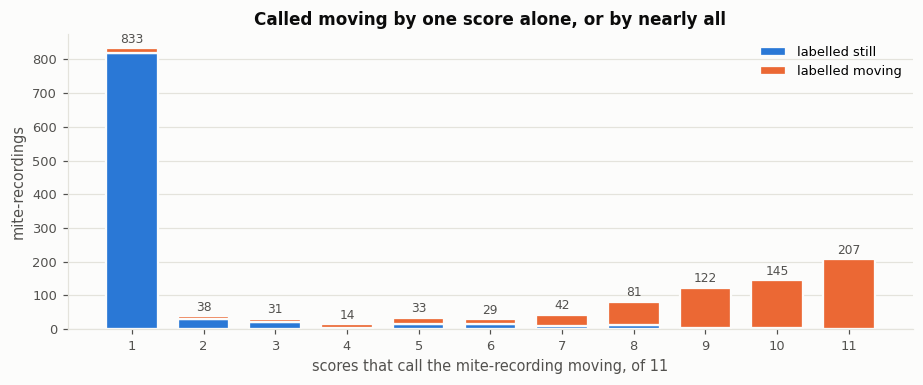

called moving by at least one score: 1575; by one alone: 833 (820 of them labelled still); by all 11: 207
labelled moving (651): called by all 207, by all but one or two 259, by fewer than half 70, by none 12
labelled still (16667): called by none 15731, by one 820, by two or more 116, by more than half 45
labelled moving, by how many scores call it: 1: 2%, 2: 21%, 3: 35%, 4: 64%, 5: 52%, 6: 52%, 7: 76%, 8: 84%, 9: 96%, 10: 98%, 11: 100%
called moving by none of the 7 that agree and by at least one of the 4 apart: 803 mite-recordings, 11 of them labelled moving; labelled moving and called by none of the 7 that agree: 23


,topN_temporal_range,topN_variability,vector_variance,outline_movement,topN_vector_temporal_range,max_diff,vector_diff,optical_flow,leg_tracker,mean_diff,topN_binary_flux
calls it moving alone,1,0,1,1,2,10,28,134,153,199,304
"of those, labelled moving",0,0,0,1,1,2,0,5,4,0,0
the only one of 11 that does not,0,0,0,0,1,0,3,40,17,23,61


In [6]:
called = CALLS["same count"]
n_votes = ma.votes(called)
count = lambda where: np.bincount(n_votes[where], minlength=len(names) + 1)[1:]
x = np.arange(1, len(names) + 1)
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.bar(x, count(is_still), color=BLUE, width=0.72, edgecolor=SURFACE, linewidth=1.5, label="labelled still")
ax.bar(x, count(moving), bottom=count(is_still), color=ORANGE, width=0.72, edgecolor=SURFACE, linewidth=1.5, label="labelled moving")
for at, total in zip(x, count(labelled)):
    ax.text(at, total + 8, str(total), ha="center", va="bottom", fontsize=8, color=MUTED)
ax.set_xticks(x)
ax.set_xlabel(f"scores that call the mite-recording moving, of {len(names)}")
ax.set_ylabel("mite-recordings")
ax.set_title("Called moving by one score alone, or by nearly all")
ax.grid(axis="x", visible=False)
ax.legend()
plt.tight_layout()
plt.show()

some = labelled & (n_votes > 0)
print(f"called moving by at least one score: {some.sum()}; by one alone: {(labelled & (n_votes == 1)).sum()} "
      f"({(is_still & (n_votes == 1)).sum()} of them labelled still); by all {len(names)}: {(labelled & (n_votes == len(names))).sum()}")
print(f"labelled moving ({moving.sum()}): called by all {(moving & (n_votes == len(names))).sum()}, by all but one or two "
      f"{(moving & (n_votes >= len(names) - 2) & (n_votes < len(names))).sum()}, by fewer than half {(moving & (n_votes < len(names) / 2)).sum()}, "
      f"by none {(moving & (n_votes == 0)).sum()}")
print(f"labelled still ({is_still.sum()}): called by none {(is_still & (n_votes == 0)).sum()}, by one {(is_still & (n_votes == 1)).sum()}, "
      f"by two or more {(is_still & (n_votes >= 2)).sum()}, by more than half {(is_still & (n_votes > len(names) / 2)).sum()}")
print("labelled moving, by how many scores call it: " + ", ".join(f"{k}: {moving[labelled & (n_votes == k)].mean():.0%}" for k in x))
# do the ones apart see what the ones that agree miss?
by_close, by_apart = (ma.votes({name: called[name] for name in group}) for group in (CLOSE, APART))
print(f"called moving by none of {THE_CLOSE} and by at least one of the {len(APART)} apart: {(labelled & (by_close == 0) & (by_apart > 0)).sum()} "
      f"mite-recordings, {(moving & (by_close == 0) & (by_apart > 0)).sum()} of them labelled moving; "
      f"labelled moving and called by none of {THE_CLOSE}: {(moving & (by_close == 0)).sum()}")
alone = lambda name: labelled & (n_votes == 1) & called[name]
display(pd.DataFrame({"calls it moving alone": {name: int(alone(name).sum()) for name in ORDER},
                      "of those, labelled moving": {name: int((alone(name) & moving).sum()) for name in ORDER},
                      f"the only one of {len(names)} that does not": {name: int((labelled & (n_votes == len(names) - 1) & ~called[name]).sum()) for name in ORDER}}).T)

### Where in the run

Every mite is a row, from the first to die (by the labels) at the top to the last at the bottom; across is the run. Above: the labels. Below: how many of the scores call that recording moving.

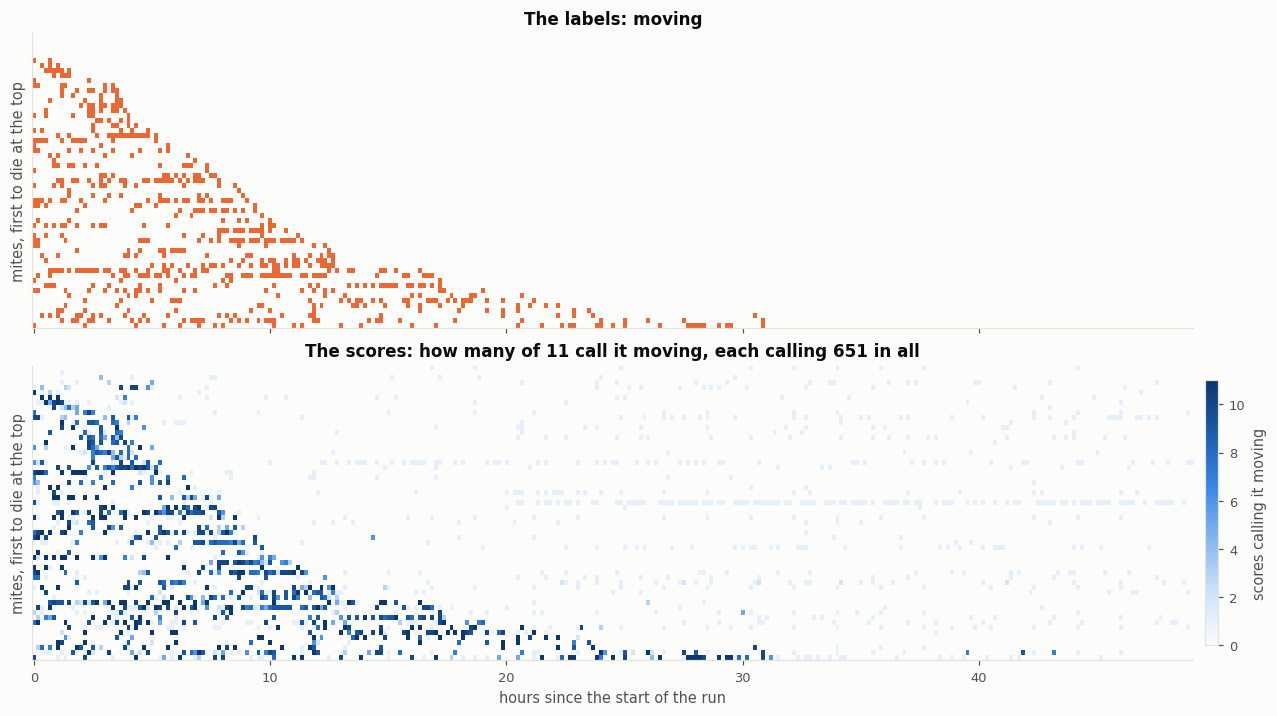

after a mite's last labelled movement: 13928 mite-recordings; called moving by one score alone 629, by two or more 36


In [7]:
by_death = np.argsort(np.where(run.moved, run.last, -1), kind="stable")
extent = (hours[0] - step / 120, hours[-1] + step / 120, n_mites - 0.5, -0.5)
fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=True, constrained_layout=True)
axes[0].imshow(np.where(labelled, moving, np.nan)[by_death], aspect="auto", cmap=ListedColormap([SURFACE, ORANGE]), vmin=0, vmax=1,
               extent=extent, interpolation="nearest")
axes[0].set_title("The labels: moving")
shown = axes[1].imshow(n_votes[by_death], aspect="auto", cmap=AMOUNT, vmin=0, vmax=len(names), extent=extent, interpolation="nearest")
axes[1].set_title(f"The scores: how many of {len(names)} call it moving, each calling {moving.sum()} in all")
axes[1].set_xlabel("hours since the start of the run")
for ax in axes:
    ax.grid(False)
    ax.set_yticks([])
    ax.set_ylabel("mites, first to die at the top")
fig.colorbar(shown, ax=axes[1], shrink=0.9, pad=0.01, label="scores calling it moving")
plt.show()

after = labelled & (np.arange(n_recordings)[None] > np.where(run.moved, run.last, -1)[:, None])   # after the mite's last labelled movement
print(f"after a mite's last labelled movement: {after.sum()} mite-recordings; called moving by one score alone {(after & (n_votes == 1)).sum()}, "
      f"by two or more {(after & (n_votes >= 2)).sum()}")

### What the split ones look like

Each picture shows where the pixels of one mite vary over the 10 frames of one recording (the brighter, the more), which is what most of the scores are made of. Top: recordings labelled still that most scores call moving. Middle: recordings labelled moving that no score calls moving. Bottom: recordings the scores are split on, with the label.

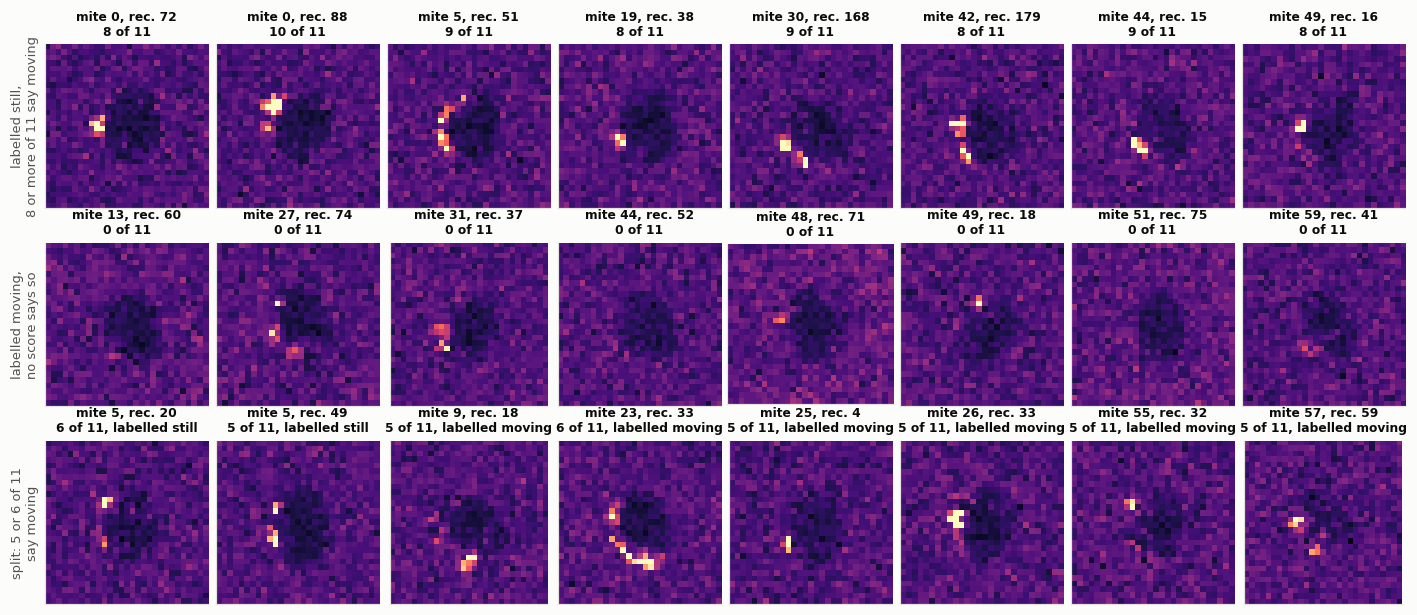

labelled still, 8 or more of 11 say moving (21), as mite/recording: 0/72, 0/80, 0/88, 0/139, 3/54, 4/32, 5/51, 19/38, 22/24, 23/40, 26/39, 27/71, 30/168, 30/251, 31/118, 37/47, 42/179, 42/181, 44/14, 44/15, 49/16
labelled moving, no score says so (12), as mite/recording: 13/60, 20/13, 27/74, 31/37, 32/54, 40/76, 44/52, 45/44, 48/71, 49/18, 51/75, 59/41


In [8]:
MOST = len(names) - 3   # "most scores": all but three, or more
kinds = [(f"labelled still,\n{MOST} or more of {len(names)} say moving", is_still & (n_votes >= MOST)),
         ("labelled moving,\nno score says so", moving & (n_votes == 0)),
         (f"split: 5 or 6 of {len(names)}\nsay moving", labelled & (n_votes >= 5) & (n_votes <= 6))]
rng = np.random.default_rng(1)
fig, axes = plt.subplots(len(kinds), 8, figsize=(13, 5.6))
for row, (title, where) in enumerate(kinds):
    cells = np.argwhere(where)
    for ax, (mite, recording) in zip(axes[row], cells[np.sort(rng.choice(len(cells), min(8, len(cells)), replace=False))]):
        frames = run.grey(mite)[recording]
        ax.imshow(frames.std(axis=0), cmap="magma", vmin=0, vmax=6)
        ax.set_xlim(7.5, frames.shape[2] - 8.5); ax.set_ylim(frames.shape[1] - 8.5, 7.5)
        label = (", labelled moving" if moving[mite, recording] else ", labelled still") if row == 2 else ""
        ax.set_title(f"mite {run.mites[mite]}, rec. {recording}\n{n_votes[mite, recording]} of {len(names)}{label}", fontsize=8)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    axes[row, 0].set_ylabel(title, fontsize=8.5)
plt.tight_layout(w_pad=0.3, h_pad=1.2)
plt.show()
for title, where in kinds[:2]:
    print(title.replace("\n", " ") + f" ({where.sum()}), as mite/recording: "
          + ", ".join(f"{run.mites[mite]}/{recording}" for mite, recording in np.argwhere(where)))

## What it does to the deaths

The analysis calls a mite alive up to the last recording in which it moves, so one call on a mite long dead keeps it alive until then. The curves give the share of the mites alive by each score, against the labels (black). Left: at the saved thresholds, as the app has them. Right: each score at its best threshold for the deaths of this run.

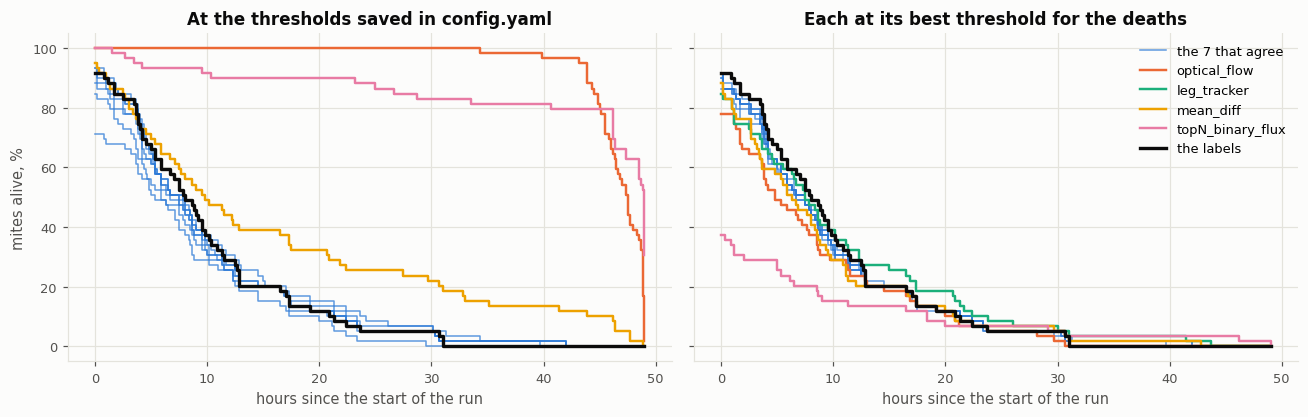

half the mites are dead after: the labels 8.0 h
  saved: topN_temporal_range 5.8, topN_variability 7.5, vector_variance 7.8, outline_movement 7.5, topN_vector_temporal_range 5.3, max_diff 7.8, vector_diff 6.7, optical_flow 47.5, mean_diff 9.8, topN_binary_flux 49.0
  best for deaths: topN_temporal_range 7.5, topN_variability 7.5, vector_variance 7.5, outline_movement 7.5, topN_vector_temporal_range 6.7, max_diff 7.5, vector_diff 6.7, optical_flow 4.8, leg_tracker 7.5, mean_diff 6.3, topN_binary_flux 0.0


In [9]:
def alive(called):
    """The share of the mites alive at each recording: a mite is alive up to the last recording it is called moving in."""
    called = called & labelled
    return 100 * (np.cumsum(called[:, ::-1], axis=1)[:, ::-1] > 0).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
for ax, key, title in zip(axes, ("saved", "best for deaths"), ("At the thresholds saved in config.yaml", "Each at its best threshold for the deaths")):
    for name in ORDER:
        if name in CALLS[key]:
            close = name in CLOSE
            ax.plot(hours, alive(CALLS[key][name]), drawstyle="steps-post", color=BLUE if close else APART_COLORS.get(name, GREY),
                    linewidth=1.0 if close else 1.6, alpha=0.75 if close else 1, zorder=2 if close else 3,
                    label=THE_CLOSE if name == CLOSE[0] else None if close else name)
    ax.plot(hours, alive(moving), drawstyle="steps-post", color=INK, linewidth=2.2, zorder=4, label="the labels")
    ax.set_title(title)
    ax.set_xlabel("hours since the start of the run")
axes[0].set_ylabel("mites alive, %")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

half = lambda called: hours[np.argmax(alive(called) <= 50)] if (alive(called) <= 50).any() else np.nan
print(f"half the mites are dead after: the labels {half(moving):.1f} h")
for key in ("saved", "best for deaths"):
    print(f"  {key}: " + ", ".join(f"{name} {half(CALLS[key][name]):.1f}" for name in ORDER if name in CALLS[key]))

### Mite by mite

Each score at its best threshold for the deaths. Every column is a mite, from the first to die by the labels to the last; every row a score. The colour is how far the score puts the death from where the labels put it: red later, blue earlier, grey the same recording. The scale stops at 30 recordings (5 hours) either way.

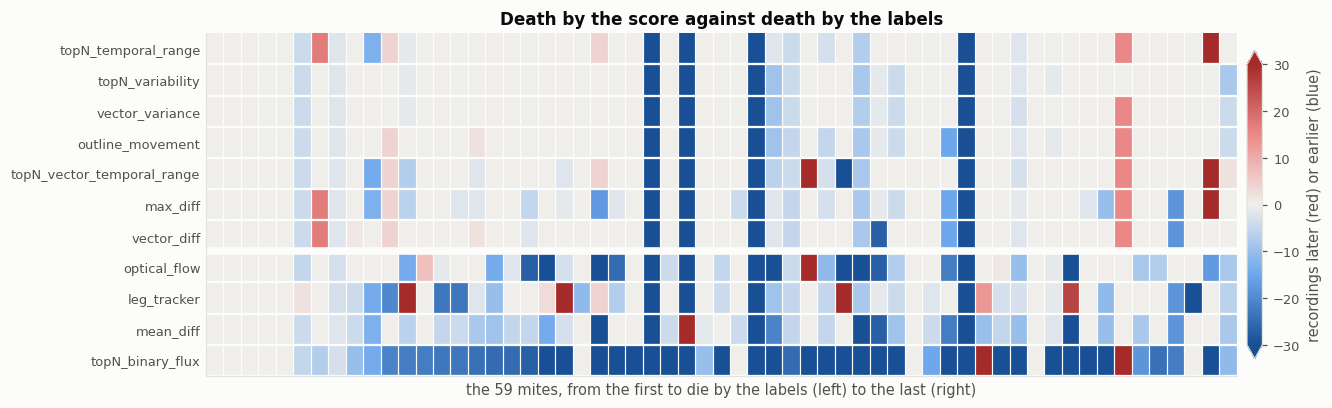

,same recording,within 3 recordings,more than 3 later,more than 3 earlier,mean distance
topN_temporal_range,41,46,5,8,5.051
topN_variability,44,49,0,10,3.492
vector_variance,44,48,1,10,3.644
outline_movement,40,45,2,12,4.220
topN_vector_temporal_range,37,43,5,11,6.576
max_diff,29,39,4,16,6.508
vector_diff,40,46,3,10,4.712
optical_flow,24,30,2,27,12.085
leg_tracker,22,31,6,22,16.864
mean_diff,21,25,1,33,12.559


saved, the 7 that agree: a mite's death differs between them by 7 recordings in the middle; by 3 or fewer for 17 mites, by more than 30 for 9
same count, the 7 that agree: a mite's death differs between them by 2 recordings in the middle; by 3 or fewer for 39 mites, by more than 30 for 8
best for deaths, the 7 that agree: a mite's death differs between them by 1 recordings in the middle; by 3 or fewer for 37 mites, by more than 30 for 2
mites that all of the 7 that agree put more than 3 recordings off, the same way: 7 (7 earlier, 0 later)
best for deaths: of the 54 last labelled movements, 10 are called moving by no score and 20 by fewer than half; of all the 651 labelled movements, 40 and 162
same count: of the 54 last labelled movements, 7 are called moving by no score and 11 by fewer than half; of all the 651 labelled movements, 12 and 70


In [10]:
called = CALLS["best for deaths"]
errors = np.array([death_error(called[name]) for name in ORDER])
fig, ax = plt.subplots(figsize=(12, 3.6), constrained_layout=True)
shown = ax.imshow(errors[:, by_death], aspect="auto", cmap=SIDES, vmin=-30, vmax=30, interpolation="nearest")
ax.set_yticks(range(len(ORDER)), ORDER)
ax.set_xticks([])
ax.set_xlabel(f"the {n_mites} mites, from the first to die by the labels (left) to the last (right)")
ax.grid(False); ax.tick_params(length=0)
for edge in np.arange(0.5, len(ORDER)):
    ax.axhline(edge, color=SURFACE, linewidth=5 if edge + 0.5 == len(CLOSE) else 1.5)
for edge in np.arange(0.5, n_mites):
    ax.axvline(edge, color=SURFACE, linewidth=0.8)
ax.set_title("Death by the score against death by the labels")
fig.colorbar(shown, ax=ax, shrink=0.9, pad=0.01, extend="both", label="recordings later (red) or earlier (blue)")
plt.show()

display(pd.DataFrame({name: {"same recording": int((error == 0).sum()), "within 3 recordings": int((np.abs(error) <= 3).sum()),
                             "more than 3 later": int((error > 3).sum()), "more than 3 earlier": int((error < -3).sum()),
                             "mean distance": float(np.abs(error).mean())} for name, error in zip(ORDER, errors)}).T
        .astype({"same recording": int, "within 3 recordings": int, "more than 3 later": int, "more than 3 earlier": int}))
died = {key: np.array([ma.deaths(run, CALLS[key][name]) for name in CLOSE if name in CALLS[key]]) for key in CALLS}
for key, at in died.items():
    spread = at.max(axis=0) - at.min(axis=0)
    print(f"{key}, {THE_CLOSE}: a mite's death differs between them by {np.median(spread):.0f} recordings in the middle; "
          f"by 3 or fewer for {(spread <= 3).sum()} mites, by more than 30 for {(spread > 30).sum()}")
same_way = (np.sign(errors[:len(CLOSE)]) == np.sign(errors[0])).all(axis=0) & (np.abs(errors[:len(CLOSE)]) > 3).all(axis=0)
print(f"mites that all of {THE_CLOSE} put more than 3 recordings off, the same way: {same_way.sum()} "
      f"({(same_way & (errors[0] < 0)).sum()} earlier, {(same_way & (errors[0] > 0)).sum()} later)")

# a mite's death hangs on its last labelled movement: how many scores see those?
is_last = moving & (np.arange(n_recordings)[None] == run.last[:, None])
for key in ("best for deaths", "same count"):
    n = ma.votes(CALLS[key])
    print(f"{key}: of the {is_last.sum()} last labelled movements, {(is_last & (n == 0)).sum()} are called moving by no score and "
          f"{(is_last & (n < len(names) / 2)).sum()} by fewer than half; of all the {moving.sum()} labelled movements, "
          f"{(moving & (n == 0)).sum()} and {(moving & (n < len(names) / 2)).sum()}")

## The order of the mites over the run

Can the scores say which mite moved most over the run and which least? A mite's movement over the run is summed up in five ways, and for each the scores are asked how far they put the mites in the same order as each other (**Kendall's W**: 1 the same order, 0 nothing in common) and as the labels (**Spearman's rank correlation**, against the number of recordings labelled moving, or against the death by the labels).

- **mean score**: the mean of the mite's scores over the run, as they come.
- **mean score above its own floor**: a still mite does not score 0, and each mite has its own floor. The floor is taken as the median of the mite's scores (it is still in most recordings), and only what is above it counts.
- **recordings called moving** at the same count.
- **death**, the recording after the last one called moving, at the same count and at the best threshold for the deaths.

In [11]:
total = ma.per_mite(run, table, CALLS["same count"])
at_best = ma.per_mite(run, table, CALLS["best for deaths"])
n_moving, death = moving.sum(axis=1), ma.deaths(run, moving)   # by the labels
ways = {"mean score": (total["mean_score"], n_moving),
        "mean score above its own floor": (total["above_floor"], n_moving),
        "recordings called moving (same count)": (total["moving"], n_moving),
        "death (same count)": (total["death"], death),
        "death (best for deaths)": (at_best["death"], death)}
with_labels = pd.DataFrame({way: {name: ma.rank_correlation(values[name], reference) for name in ORDER} for way, (values, reference) in ways.items()})
display(pd.DataFrame({way: {"Kendall's W, all": ma.concordance(values), f"Kendall's W, {THE_CLOSE}": ma.concordance({name: values[name] for name in CLOSE}),
                            "with the labels: lowest": with_labels[way].min(), "median": with_labels[way].median(), "highest": with_labels[way].max()}
                      for way, (values, _reference) in ways.items()}).T)
print("each score's order of the mites against the labels' (Spearman):")
display(with_labels)

,"Kendall's W, all","Kendall's W, the 7 that agree",with the labels: lowest,median,highest
mean score,0.473,0.721,-0.072,0.543,0.886
mean score above its own floor,0.836,0.973,0.487,0.947,0.976
recordings called moving (same count),0.820,0.983,0.557,0.963,0.988
death (same count),0.635,0.959,0.294,0.922,0.936
death (best for deaths),0.879,0.983,0.599,0.940,0.949


each score's order of the mites against the labels' (Spearman):


,mean score,mean score above its own floor,recordings called moving (same count),death (same count),death (best for deaths)
topN_temporal_range,0.857,0.976,0.981,0.927,0.949
topN_variability,0.542,0.955,0.988,0.922,0.948
vector_variance,0.840,0.947,0.978,0.929,0.948
outline_movement,0.744,0.973,0.985,0.936,0.940
topN_vector_temporal_range,0.886,0.975,0.979,0.928,0.910
max_diff,0.844,0.966,0.963,0.931,0.941
vector_diff,0.386,0.932,0.963,0.852,0.942
optical_flow,0.543,0.813,0.849,0.294,0.833
leg_tracker,0.227,0.787,0.853,0.624,0.829
mean_diff,-0.072,0.870,0.675,0.500,0.870


The same as a picture, for the two ways that need no threshold. Every column is a mite, from the one labelled moving in the most recordings (left) to the ones never labelled moving (right). The colour is the mite's rank by that score: the darker, the more it moved. A score that puts the mites in the labels' order goes from dark to light like the top row.

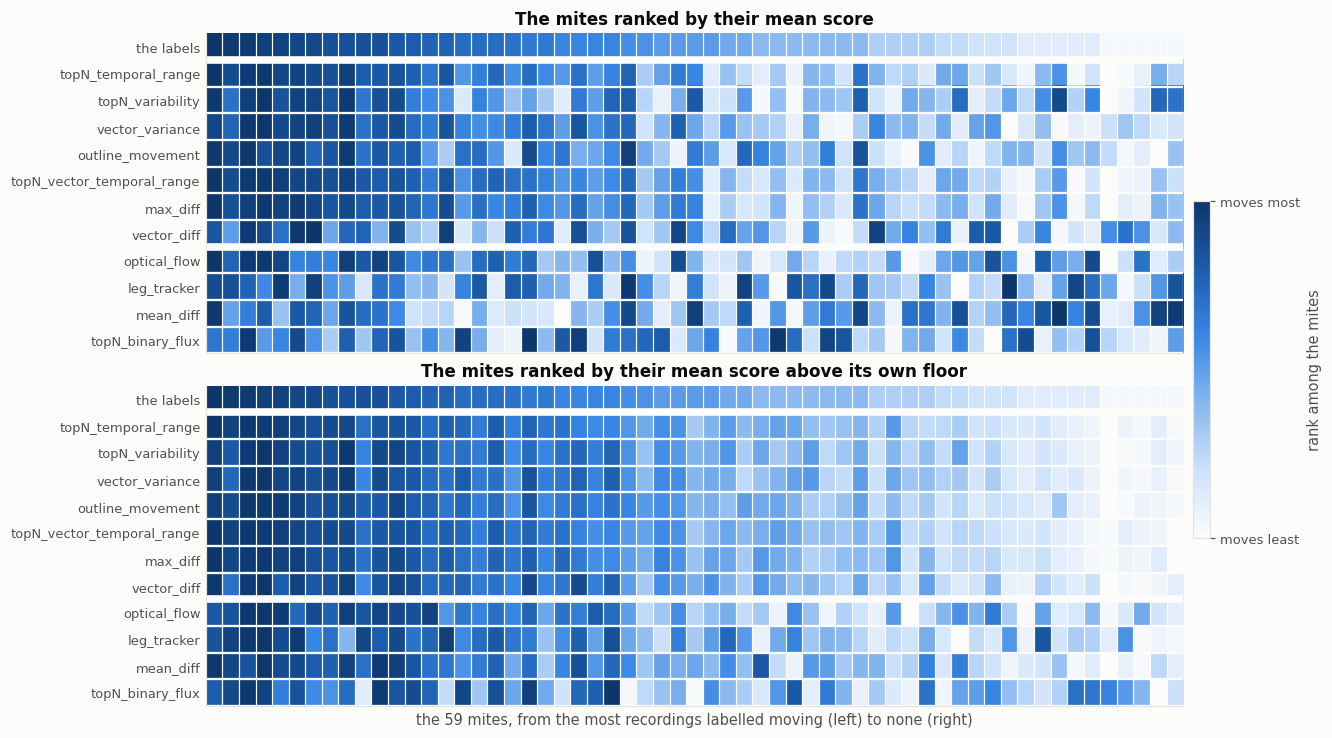

In [12]:
by_labels = np.argsort(-n_moving, kind="stable")
fig, axes = plt.subplots(2, 1, figsize=(12, 6.6), sharex=True, constrained_layout=True)
for ax, way in zip(axes, ("mean score", "mean score above its own floor")):
    values = ways[way][0]
    ranks = np.array([rankdata(n_moving)] + [rankdata(values[name]) for name in ORDER])
    shown = ax.imshow(ranks[:, by_labels], aspect="auto", cmap=AMOUNT, vmin=1, vmax=n_mites, interpolation="nearest")
    ax.set_yticks(range(len(ORDER) + 1), ["the labels"] + ORDER)
    ax.set_xticks([]); ax.grid(False); ax.tick_params(length=0)
    for edge in np.arange(0.5, len(ORDER) + 1):
        ax.axhline(edge, color=SURFACE, linewidth=5 if edge in (0.5, len(CLOSE) + 0.5) else 1.5)
    for edge in np.arange(0.5, n_mites):
        ax.axvline(edge, color=SURFACE, linewidth=0.8)
    ax.set_title(f"The mites ranked by their {way}")
axes[1].set_xlabel(f"the {n_mites} mites, from the most recordings labelled moving (left) to none (right)")
bar = fig.colorbar(shown, ax=axes, shrink=0.5, pad=0.01, ticks=[1, n_mites], label="rank among the mites")
bar.ax.set_yticklabels(["moves least", "moves most"])
plt.show()

## The order of the mites within a recording

The same question at one moment: of the mites of one recording, do the scores agree which moves more? The rank correlation is taken among the mites of one recording and averaged over the recordings. Left: among the mites labelled moving in that recording (the recordings with 5 or more of them). Right: among the mites labelled still.

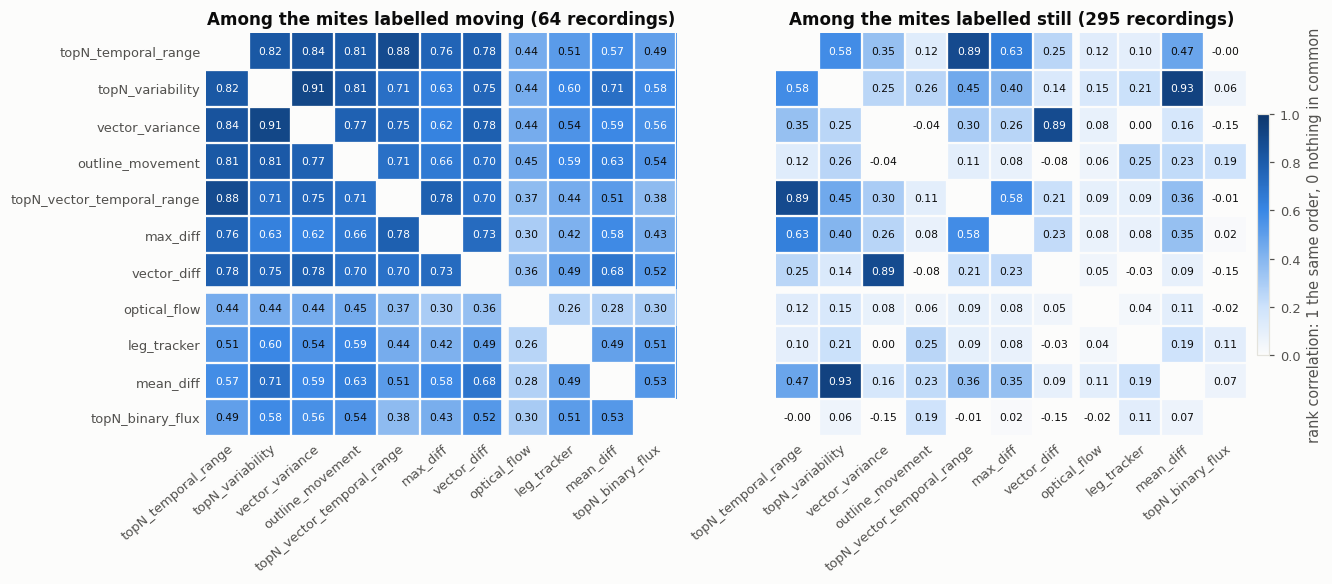

among the mites labelled moving: mean of all pairs 0.59; among the 7 that agree 0.76
among the mites labelled still: mean of all pairs 0.20; among the 7 that agree 0.33


,topN_temporal_range,topN_variability,vector_variance,outline_movement,topN_vector_temporal_range,max_diff,vector_diff,optical_flow,leg_tracker,mean_diff,topN_binary_flux
its top mite is labelled moving,0.993,0.993,1.000,0.986,0.986,0.986,0.993,0.917,0.938,0.951,0.917
"the same mite as another score's, in the mean",0.705,0.710,0.705,0.678,0.628,0.610,0.676,0.489,0.499,0.590,0.557


144 recordings have a mite labelled moving; the mite scoring highest is the same for all 11 scores in 19% of them, for the 7 that agree in 49%


In [13]:
def within_recording(where):
    """Per pair of scores, the mean over the recordings of their rank correlation among the mites of `where`; and the recordings used."""
    out = np.full((len(ORDER), len(ORDER)), np.nan)
    used = 0
    for i, first in enumerate(ORDER):
        for j in range(i + 1, len(ORDER)):
            each = ma.by_recording(table[first], table[ORDER[j]], where)
            out[i, j] = out[j, i] = np.nanmean(each)
            used = int(np.isfinite(each).sum())
    return out, used

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, constrained_layout=True)
orders = {}
for ax, (title, where) in zip(axes, (("Among the mites labelled moving", moving), ("Among the mites labelled still", is_still))):
    orders[title], used = within_recording(where)
    shown = number_grid(ax, orders[title], ORDER, split=(len(CLOSE),))
    ax.set_title(f"{title} ({used} recordings)")
fig.colorbar(shown, ax=axes, shrink=0.6, pad=0.01, label="rank correlation: 1 the same order, 0 nothing in common")
plt.show()
for title, matrix in orders.items():
    print(f"{title.lower()}: mean of all pairs {np.nanmean(matrix):.2f}; among {THE_CLOSE} {np.nanmean(matrix[:len(CLOSE), :len(CLOSE)]):.2f}")

# the mite that moves most in a recording: is it the same one for every score?
with_movement = np.flatnonzero(moving.any(axis=0))
top = {name: np.where(labelled, table[name], -np.inf)[:, with_movement].argmax(axis=0) for name in ORDER}
display(pd.DataFrame({"its top mite is labelled moving": {name: moving[top[name], with_movement].mean() for name in ORDER},
                      "the same mite as another score's, in the mean": {name: np.mean([(top[name] == top[other]).mean() for other in ORDER if other != name])
                                                                        for name in ORDER}}).T)
same_for = lambda group: (np.array([top[name] for name in group]) == top[group[0]]).all(axis=0).mean()
print(f"{len(with_movement)} recordings have a mite labelled moving; the mite scoring highest is the same for all {len(ORDER)} scores in "
      f"{same_for(ORDER):.0%} of them, for {THE_CLOSE} in {same_for(CLOSE):.0%}")

## When they disagree, who is right?

The labels are the only reference here. If the scores were wrong in different places, a vote would do better than any one of them: a mite-recording is called moving when at least *k* of the scores call it so. The table gives the vote at every *k*, for the scores at the same count and at their best thresholds, next to the best single score of each.

In [14]:
def judged(called):
    error = death_error(called)
    return {"called moving": int((called & labelled).sum()), "of the moving found": (called & moving).sum() / moving.sum(),
            "of them still": int((called & is_still).sum()), "death error": float(np.abs(error).mean()), "deaths in the same recording": int((error == 0).sum())}

rows = {}
for key in ("same count", "best for deaths"):
    n = ma.votes(CALLS[key])
    single = {name: judged(CALLS[key][name]) for name in ORDER}
    best_single = min(single, key=lambda name: single[name]["death error"])
    rows[(key, f"best single score: {best_single}")] = single[best_single]
    for k in range(1, len(ORDER) + 1):
        rows[(key, f"at least {k} of {len(ORDER)}")] = judged(n >= k)
votes_table = pd.DataFrame(rows).T.astype({"called moving": int, "of them still": int, "deaths in the same recording": int})
display(votes_table)

called moving  \
same count      best single score: outline_movement            651   
                at least 1 of 11                              1575   
                at least 2 of 11                               742   
                at least 3 of 11                               704   
                at least 4 of 11                               673   
                at least 5 of 11                               659   
                at least 6 of 11                               626   
                at least 7 of 11                               597   
                at least 8 of 11                               555   
                at least 9 of 11                               474   
                at least 10 of 11                              352   
                at least 11 of 11                              207   
best for deaths best single score: topN_variability            511   
                at least 1 of 11                               725   
                at least 2 of 11                               620   
                at least 3 of 11                               589   
                at least 4 of 11                               562   
                at least 5 of 11                               535   
                at least 6 of 11                               493   
                at least 7 of 11                               460   
                at least 8 of 11                               406   
                at least 9 of 11                               289   
                at least 10 of 11                              175   
                at least 11 of 11                               73   

                                                     of the moving found  \
same count      best single score: outline_movement                0.914   
                at least 1 of 11                                   0.982   
                at least 2 of 11                                   0.962   
                at least 3 of 11                                   0.949   
                at least 4 of 11                                   0.932   
                at least 5 of 11                                   0.919   
                at least 6 of 11                                   0.892   
                at least 7 of 11                                   0.869   
                at least 8 of 11                                   0.820   
                at least 9 of 11                                   0.716   
                at least 10 of 11                                  0.536   
                at least 11 of 11                                  0.318   
best for deaths best single score: topN_variability                0.782   
                at least 1 of 11                                   0.939   
                at least 2 of 11                                   0.897   
                at least 3 of 11                                   0.868   
                at least 4 of 11                                   0.837   
                at least 5 of 11                                   0.802   
                at least 6 of 11                                   0.751   
                at least 7 of 11                                   0.705   
                at least 8 of 11                                   0.624   
                at least 9 of 11                                   0.444   
                at least 10 of 11                                  0.269   
                at least 11 of 11                                  0.112   

                                                     of them still  \
same count      best single score: outline_movement             56   
                at least 1 of 11                               936   
                at least 2 of 11                               116   
                at least 3 of 11                                86   
                at least 4 of 11                   

## What follows, and what this does not say

**What follows**

- **Which of the seven is in use changes little.** They make the same calls and rank the mites alike. The choice between them is the one `death_time_calibration.ipynb` makes, by the death error, and there the differences were within the luck of the split.
- **A threshold belongs to the kind of recording it was set on.** On a run of 10 frames, a metric other than the one in use needs its threshold calibrated on such a run before its calls mean anything. `optical_flow` also needs another `step`: with 13 it compares only the first frame of a 10-frame recording with the last one, where 30 frames give it 17 pairs to average.
- **To say which mite or group moves more, do not average raw scores.** Count the recordings called moving, or take the score above each mite's own floor, which is what the app's per-mite floor (`normalize_floor`) does to the scores.
- **A second score is not a second opinion.** The four apart add stray calls and hardly a movement the seven miss (11 in 803), and the seven are wrong on the same recordings. What all of them miss are weak movements, often a mite's last. Those are the ones a look by eye is for (the band of `death_time_calibration.ipynb`).
- **`topN_variability` at n = 759 is `variability`.** If the top pixels are meant, n has to be below 396, the values of the smallest box.

**What this does not say**

- It is one run, one plate and 59 mites, with 10 frames a recording. The short recordings it is set beside have 6 recordings each.
- The thresholds at the same count and the best ones for the deaths are set with this run's labels. How far two scores agree at the same count only uses how many the labels call moving, but the death errors here are the best each score can do on this run, not what it would do on a new one.
- The parameters are those in `config.yaml`. A score with other parameters is another score, and `optical_flow`'s step of 13 cannot have been chosen for recordings of 10 frames.
- That the saved thresholds fail here because of the 10 frames is my reading. For `optical_flow` it is in the code. For the others it fits what they measure (the range of a pixel over 10 frames is smaller than over 30), but the short recordings also differ in frame rate (30 a second against 14) and in day, and nothing here tells those apart.
- The labels are the reference for the order of the mites and for the deaths. Where most scores go against a label, it may be the label.
- Abilium's benchmark is left out (it gives a call, not a score), and so is everything that tells alive from dead between recordings (`alive_dead_overview.ipynb`).